## scGNN

In [ ]:
conda activate scgnnEnv

In [ ]:
cd /disk1/cai029/biosoft/scGNN

In [ ]:
python -W ignore PreprocessingscGNN.py --datasetName scGNN_total_data.csv --datasetDir /disk1/cai029/biosoft/UNAGI/UNAGI/data/example/ --LTMGDir /disk1/cai029/biosoft/UNAGI/UNAGI/data/example/ --filetype CSV --geneSelectnum 2000

In [ ]:
python -W ignore scGNN.py --datasetName example --datasetDir /disk1/cai029/biosoft/UNAGI/UNAGI/data/ --outputDir /disk1/cai029/Caufussion/Benchmark_Disentangled/scGNN/ --EM-iteration 2 --Regu-epochs 50 --EM-epochs 20 --quickmode --nonsparseMode

In [47]:
import pandas as pd
import numpy as np
import scanpy as sc
data_path = "/disk1/cai029/Caufussion/Benchmark_Disentangled/scGNN/example_embedding.csv"
df = pd.read_csv(data_path)
df.index = df['Unnamed: 0']
df = df.drop(columns=['Unnamed: 0'])
embedding_matrix = df.values.astype(np.float32)
scGNN_adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data.h5ad")
scGNN_adata.obsm['embedding'] = embedding_matrix

In [25]:
import networkx as nx
from igraph import *

def generateLouvainCluster(edgeList):
    """
    Louvain Clustering using igraph
    """
    # edgeList_with_weights = [(u, v, 1.0) for u, v in edgeList]
    Gtmp = nx.Graph()
    Gtmp.add_weighted_edges_from(edgeList)
    W = nx.adjacency_matrix(Gtmp)
    W = W.todense()
    graph = Graph.Weighted_Adjacency(
        W.tolist(), mode=ADJ_UNDIRECTED, attr="weight", loops=False)
    louvain_partition = graph.community_multilevel(
        weights=graph.es['weight'], return_levels=False)
    size = len(louvain_partition)
    hdict = {}
    count = 0
    for i in range(size):
        tlist = louvain_partition[i]
        for j in range(len(tlist)):
            hdict[tlist[j]] = i
            count += 1

    listResult = []
    for i in range(count):
        listResult.append(hdict[i])

    return listResult, size

In [26]:
from scipy.spatial import distance_matrix, minkowski_distance, distance
import scipy.sparse
import sys
import pickle
import csv
import networkx as nx
import numpy as np
from sklearn.ensemble import IsolationForest
import time
from multiprocessing import Pool
import multiprocessing 
def calculateKNNgraphDistanceMatrix(featureMatrix, distanceType='euclidean', k=10):     
    distMat = distance.cdist(featureMatrix,featureMatrix, distanceType)
        
    edgeList=[]

    for i in np.arange(distMat.shape[0]):
        res = distMat[:,i].argsort()[:k]
        for j in np.arange(k):
            # edgeList.append((i,res[j]))
            edgeList.append((i, res[j], distMat[i, res[j]]))
    return edgeList

In [27]:
from scipy.spatial import distance_matrix, minkowski_distance, distance
import scipy.sparse
import sys
import pickle
import csv
import networkx as nx
import numpy as np
from sklearn.ensemble import IsolationForest
import time
from multiprocessing import Pool
import multiprocessing

def edgeList2edgeDict(edgeList, nodesize):
    graphdict={}
    tdict={}

    for edge in edgeList:
        end1 = edge[0]
        end2 = edge[1]
        tdict[end1]=""
        tdict[end2]=""
        if end1 in graphdict:
            tmplist = graphdict[end1]
        else:
            tmplist = []
        tmplist.append(end2)
        graphdict[end1]= tmplist

    #check and get full matrix
    for i in range(nodesize):
        if i not in tdict:
            graphdict[i]=[]

    return graphdict
    
def generateAdj(featureMatrix, graphType='KNNgraph', para = None, parallelLimit = 0, adjTag = True ):
    """
    Generating edgeList 
    """
    edgeList = None
    adj = None

    if graphType == 'KNNgraphPairwise':
        edgeList = calculateKNNgraphDistanceMatrixPairwise(featureMatrix, para)
    elif graphType == 'KNNgraph':
        if para != None:
            parawords = para.split(':')
            distanceType = parawords[0]
            k = int(parawords[1])
        edgeList = calculateKNNgraphDistanceMatrix(featureMatrix)
    elif graphType == 'Thresholdgraph':
        if para != None:
            parawords = para.split(':')
            distanceType = parawords[0]
            threshold = float(parawords[1])
        edgeList = calculateThresholdgraphDistanceMatrix(featureMatrix, distanceType=distanceType, threshold=threshold)
    elif graphType == 'KNNgraphThreshold':
        if para != None:
            parawords = para.split(':')
            distanceType = parawords[0]
            k = int(parawords[1])
            threshold = float(parawords[2])
        edgeList = calculateKNNThresholdgraphDistanceMatrix(featureMatrix, distanceType=distanceType, k=k, threshold=threshold)
    elif graphType == 'KNNgraphML':
        # with weights!
        # https://towardsdatascience.com/5-ways-to-detect-outliers-that-every-data-scientist-should-know-python-code-70a54335a623
        # https://scikit-learn.org/stable/modules/outlier_detection.html
        if para != None:
            parawords = para.split(':')
            distanceType = parawords[0]
            k = int(parawords[1])
        edgeList = calculateKNNgraphDistanceMatrixML(featureMatrix, distanceType=distanceType, k=k)
    elif graphType == 'KNNgraphStats':
        # with weights!
        # with stats, one std is contained
        if para != None:
            parawords = para.split(':')
            distanceType = parawords[0]
            k = int(parawords[1])
        edgeList = calculateKNNgraphDistanceMatrixStats(featureMatrix, distanceType=distanceType, k=k, parallelLimit=parallelLimit)
    elif graphType == 'KNNgraphStatsSingleThread':
        # with weights!
        # with stats, one std is contained, but only use single thread
        if para != None:
            parawords = para.split(':')
            distanceType = parawords[0]
            k = int(parawords[1])
        edgeList = calculateKNNgraphDistanceMatrixStatsSingleThread(featureMatrix, distanceType=distanceType, k=k)
    else:
        print('Should give graphtype')

    if adjTag:
        graphdict = edgeList2edgeDict(edgeList, featureMatrix.shape[0])
        adj = nx.adjacency_matrix(nx.from_dict_of_lists(graphdict))
    
    return adj, edgeList

In [28]:
import torch
from sklearn.cluster import KMeans, SpectralClustering, AffinityPropagation, AgglomerativeClustering, Birch, DBSCAN, FeatureAgglomeration, MeanShift, OPTICS
resolution = 0.5
z = scGNN_adata.obsm['embedding']

if isinstance(z, torch.Tensor):
    zOut = z.detach().cpu().numpy()
elif isinstance(z, np.ndarray):
    zOut = z.copy()  # 或直接 z
else:
    raise TypeError("Unsupported type for z: {}".format(type(z)))


adj, edgeList = generateAdj(zOut)
listResult, size = generateLouvainCluster(edgeList)
k = len(np.unique(listResult))
print('Louvain cluster: '+str(k))
# resolution of louvain cluster:
k = int(k*resolution) if int(k*resolution)>=3 else 2
clustering = KMeans(n_clusters=k, random_state=0).fit(zOut)
listResult = clustering.predict(zOut)

Louvain cluster: 17


In [36]:
import numpy as np
import pandas as pd
from collections import Counter

# y_true: 真实标签 (比如 ["B cell", "T cell", "Neuron", ...])
# listResult: 预测的聚类结果 (比如 [1,0,3,2,2,6,...])

df = pd.DataFrame({"true": scGNN_adata.obs['name.simple'].tolist(), "pred": listResult.tolist()})

mapping = {}
for cluster_id, group in df.groupby("pred"):
    most_common = Counter(group["true"]).most_common(1)[0][0]
    mapping[cluster_id] = most_common

print("预测簇 → 对应真实类型:")
print(mapping)

# 应用映射
y_pred_mapped = [mapping[c] for c in listResult]

预测簇 → 对应真实类型:
{0: 'VEvenous', 1: 'VEcapillary', 2: 'FibroblastAlveolar', 3: 'VEaerocyte', 4: 'SMC', 5: 'FibroblastAlveolar', 6: 'LymphEndo', 7: 'PericyteAlveolar'}


In [50]:
scGNN_adata.obs['pred'] = y_pred_mapped
scGNN_adata.write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scGNN/scGNN.h5ad")

## scGGAN

In [ ]:
conda activate unagi

In [ ]:
cd /disk1/cai029/biosoft/scGGAN

In [ ]:
python cal_net.py --rna_data=/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/scGGAN_total_data.csv --sc=1 --outdir=/disk1/cai029/Caufussion/Benchmark_Disentangled/scGGAN/

In [ ]:
python train_ggan.py  --cl 17 --n_epochs 100 --batch_size 27647 --outdir /disk1/cai029/Caufussion/Benchmark_Disentangled/scGGAN/ --rna_data /disk1/cai029/biosoft/UNAGI/UNAGI/data/example/scGGAN_total_data.csv --label /disk1/cai029/biosoft/UNAGI/UNAGI/data/example/label.csv --gene_data /disk1/cai029/biosoft/UNAGI/UNAGI/data/example/gene_kmer_features.csv --sc_net /disk1/cai029/Caufussion/Benchmark_Disentangled/scGGAN/sc.npz

In [ ]:
import pandas as pd
cell_embedding = pd.read_csv("/disk1/cai029/Caufussion/Benchmark_Disentangled/scGGAN/cell_embeddings.csv")

In [ ]:
import scanpy as sc
scGGAN_adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data.h5ad")

In [ ]:
scGGAN_adata.obsm['scGGAN_x'] = cell_embedding

In [52]:
# import scanpy as sc
# scGGAN_adata = sc.read_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scGGAN/scGGAN.h5ad")

In [81]:
import pandas as pd
label = pd.read_csv('/disk1/cai029/Caufussion/Benchmark_Disentangled/scGGAN/label.txt', sep=r'\s+', header=None, engine='python')
labels = [int(i) for i in label[0].tolist()]

In [82]:
import numpy as np
import pandas as pd
from collections import Counter

# y_true: 真实标签 (比如 ["B cell", "T cell", "Neuron", ...])
# listResult: 预测的聚类结果 (比如 [1,0,3,2,2,6,...])

df = pd.DataFrame({"true": scGGAN_adata.obs['name.simple'].tolist(), "pred": labels})

mapping = {}
for cluster_id, group in df.groupby("pred"):
    most_common = Counter(group["true"]).most_common(1)[0][0]
    mapping[cluster_id] = most_common

print("预测簇 → 对应真实类型:")
print(mapping)

# 应用映射
y_pred_mapped = [mapping[c] for c in labels]

预测簇 → 对应真实类型:
{0: 'FibroblastAlveolar', 1: 'VEcapillary', 2: 'VEcapillary', 3: 'PericyteAlveolar', 4: 'VEcapillary', 5: 'LymphEndo', 6: 'VEaerocyte', 7: 'VEcapillary', 8: 'VEvenous', 9: 'SMC', 10: 'FibroblastAlveolar', 11: 'VEaerocyte', 12: 'VEaerocyte', 13: 'VEcapillary', 14: 'VEcapillary', 15: 'VEarterial', 16: 'FibroblastAlveolar'}


In [86]:
scGGAN_adata.obs['pred'] = y_pred_mapped

In [87]:
scGGAN_adata.write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scGGAN/scGGAN.h5ad")

## GraphSCC

In [ ]:
conda activate GraphSCC

In [ ]:
cd /disk1/cai029/biosoft/GraphSCC

In [ ]:
python GraphSCC.py --device -1 --name /disk1/cai029/biosoft/UNAGI/UNAGI/data/example --train_epoch 400 --outdir /disk1/cai029/Caufussion/Benchmark_Disentangled/GraphSCC/

In [ ]:
import numpy as np 

In [16]:
z_embedding = np.load('/disk1/cai029/Caufussion/Benchmark_Disentangled/GraphSCC/z_embeddings.npy')

In [17]:
import scanpy as sc
GraphSCC_adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data.h5ad")

In [18]:
GraphSCC_adata.obsm['X_GraphSCC'] = z_embedding

In [19]:
import numpy as np
cell_label = np.load('/disk1/cai029/Caufussion/Benchmark_Disentangled/GraphSCC/cluster_predictions.npy').tolist()

In [20]:
import numpy as np
import pandas as pd
from collections import Counter

# y_true: 真实标签 (比如 ["B cell", "T cell", "Neuron", ...])
# listResult: 预测的聚类结果 (比如 [1,0,3,2,2,6,...])

df = pd.DataFrame({"true": GraphSCC_adata.obs['name.simple'].tolist(), "pred": cell_label})

mapping = {}
for cluster_id, group in df.groupby("pred"):
    most_common = Counter(group["true"]).most_common(1)[0][0]
    mapping[cluster_id] = most_common

print("预测簇 → 对应真实类型:")
print(mapping)

# 应用映射
y_pred_mapped = [mapping[c] for c in cell_label]

预测簇 → 对应真实类型:
{0: 'VEaerocyte', 1: 'FibroblastAlveolar', 2: 'VEcapillary', 3: 'PericyteAlveolar', 4: 'VEcapillary', 8: 'PericyteAlveolar', 9: 'LymphEndo', 10: 'VEvenous', 12: 'SMC', 15: 'VEaerocyte', 16: 'FibroblastAlveolar'}


In [21]:
GraphSCC_adata.obs['pred'] = y_pred_mapped

In [22]:
GraphSCC_adata.write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/GraphSCC/GraphSCC.h5ad")

In [17]:
from sklearn.cluster import KMeans
from sklearn.utils import check_array
import numpy as np
def get_labels(X, labels):
    X = check_array(X, accept_sparse=False, ensure_2d=True)
    n_clusters = len(np.unique(labels))   # 真实标签里的类别数
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(X)
    labels_pred = kmeans.labels_
    return labels_pred


## scVI

In [ ]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch

In [ ]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

In [ ]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [ ]:
adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data.h5ad")

In [ ]:
adata.layers["counts"] = adata.X.copy()

In [ ]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="Sample.ID"
)

In [ ]:
model = scvi.model.SCVI(adata, n_layers=2, n_latent=30)

In [ ]:
model.train(max_epochs = 300)

In [ ]:
model_dir = os.path.join(save_dir.name, "/disk1/cai029/Caufussion/Benchmark_Disentangled/scVI/scvi_model_1")
model.save(model_dir, overwrite=True)

In [ ]:
model = scvi.model.SCVI.load(model_dir, adata=adata)

In [ ]:
SCVI_LATENT_KEY = "X_scVI"
latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

In [ ]:
adata.write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scVI/scvi_model_1/scVI.h5ad")

In [72]:
import scanpy as sc
scVI_adata = sc.read_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scVI/scvi_model_1/scVI.h5ad")

In [112]:
labels = get_labels(X=scVI_adata.obsm['X_scVI'],labels=scVI_adata.obs['name.simple'].tolist()).tolist()

In [118]:
import numpy as np
import pandas as pd
from collections import Counter

# y_true: 真实标签 (比如 ["B cell", "T cell", "Neuron", ...])
# listResult: 预测的聚类结果 (比如 [1,0,3,2,2,6,...])

df = pd.DataFrame({"true": scVI_adata.obs['name.simple'].tolist(), "pred": labels})

mapping = {}
for cluster_id, group in df.groupby("pred"):
    most_common = Counter(group["true"]).most_common(1)[0][0]
    mapping[cluster_id] = most_common

print("预测簇 → 对应真实类型:")
print(mapping)

# 应用映射
y_pred_mapped = [mapping[c] for c in labels]

预测簇 → 对应真实类型:
{0: 'VEvenous', 1: 'VEvenous', 2: 'FibroblastAlveolar', 3: 'VEcapillary', 4: 'VEaerocyte', 5: 'PericyteAlveolar', 6: 'VEcapillary', 7: 'LymphEndo', 8: 'VEaerocyte', 9: 'FibroblastAlveolar', 10: 'FibroblastAirway', 11: 'VEcapillary', 12: 'VEcapillary', 13: 'VEarterial', 14: 'SMC', 15: 'FibroblastAdventitial', 16: 'VEaerocyte'}


In [123]:
scVI_adata.obs['pred'] = y_pred_mapped

In [126]:
scVI_adata.write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scVI/scvi_model_1/scVI.h5ad")

## scGEN

In [1]:
import logging
import scanpy as sc
import scgen

/disk1/cai029/anaconda3/envs/scgen/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data.h5ad")

In [3]:
scgen.SCGEN.setup_anndata(adata, batch_key="stage", labels_key="name.simple")

In [4]:
model = scgen.SCGEN(adata)
model.save("./Benchmark_Disentangled/scGen/saved_models/model_perturbation_prediction.pt", overwrite=True)

In [5]:
model.train(
    max_epochs=100,
    batch_size=32,
    early_stopping=True,
    early_stopping_patience=25
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/disk1/cai029/anaconda3/envs/scgen/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/disk1/cai029/anaconda3/envs/scgen/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not 

Epoch 27/100:  27%|▎| 27/100 [01:13<03:19,  2.73s/it, v_num=1, train_loss_step
Monitored metric elbo_validation did not improve in the last 25 records. Best score: 2108.221. Signaling Trainer to stop.


In [6]:
latent_X = model.get_latent_representation()
latent_adata = sc.AnnData(X=latent_X, obs=adata.obs.copy())

In [9]:
adata.obsm['X_scgen'] = latent_adata.X

In [10]:
scGen_adata = adata

In [18]:
labels = get_labels(X=scGen_adata.obsm['X_scgen'],labels=scGen_adata.obs['name.simple'].tolist()).tolist()

In [20]:
import numpy as np
import pandas as pd
from collections import Counter

# y_true: 真实标签 (比如 ["B cell", "T cell", "Neuron", ...])
# listResult: 预测的聚类结果 (比如 [1,0,3,2,2,6,...])

df = pd.DataFrame({"true": scGen_adata.obs['name.simple'].tolist(), "pred": labels})

mapping = {}
for cluster_id, group in df.groupby("pred"):
    most_common = Counter(group["true"]).most_common(1)[0][0]
    mapping[cluster_id] = most_common

print("预测簇 → 对应真实类型:")
print(mapping)

# 应用映射
y_pred_mapped = [mapping[c] for c in labels]

预测簇 → 对应真实类型:
{0: 'VEaerocyte', 1: 'VEcapillary', 2: 'FibroblastAlveolar', 3: 'VEarterial', 4: 'FibroblastAdventitial', 5: 'VEcapillary', 6: 'FibroblastAdventitial', 7: 'FibroblastAirway', 8: 'VEcapillary', 9: 'SMC', 10: 'VEvenous', 11: 'FibroblastAlveolar', 12: 'FibroblastAlveolar', 13: 'VEaerocyte', 14: 'VEvenous', 15: 'PericyteAlveolar', 16: 'LymphEndo'}


In [23]:
scGen_adata.obs['pred'] = y_pred_mapped

In [25]:
scGen_adata.write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scGen/scGEN.h5ad")

In [24]:
scGen_adata

AnnData object with n_obs × n_vars = 27647 × 2484
    obs: 'barcode', 'nUMI', 'nGene', 'percMito', 'percSpliced.v', 'percUnspliced.v', 'percAmbiguous.v', 'Sample.ID', 'Subject.ID', 'Sex', 'Age', 'Surface.Density', 'Percent.Tissue', 'Disease.Ident', 'nCount_RNA', 'final.ident', 'nFeature_RNA', 'nCount_integrated', 'nFeature_integrated', 'name.simple', 'Library.Ident', 'renamedFin', 'integrated_snn_res.2', 'seurat_clusters', 'renamed.2', 'integrated_snn_res.3', 'log10UMI', 'renamed.3', 'stage', 'leiden', 'ident', '_scvi_batch', '_scvi_labels', 'pred'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'umap', 'z', 'X_scgen'
    layers: 'geneWeight'

## UNAGI

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from UNAGI import UNAGI
unagi = UNAGI()

In [ ]:
unagi.setup_data('/disk1/cai029/biosoft/UNAGI/UNAGI/data/example',total_stage=4,stage_key='stage')

In [ ]:
unagi.setup_training('example',dist='ziln',device='cuda:0',GPU=True,epoch_iter=3,epoch_initial=2,max_iter=4,BATCHSIZE=512)

In [ ]:
iDREM_Path = '/disk1/cai029/biosoft/idrem' # path to iDREM directory
unagi.run_UNAGI(iDREM_Path)

In [ ]:
import scanpy as sc
UNAGI_adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/3/stagedata/dataset.h5ad")

In [ ]:
UNAGI_adata.obsm['z'].shape

## Caunagi

In [ ]:
import sys
sys.path.append('/disk1/cai029/Caufussion/n_caunagi/')
from n_caunagi import caunagi_main

In [ ]:
concept_list = ['stage','name.simple']
concept_cdag = [[0,0,0],[1,0,0],[0,0,0]]
state_idx = {0:0,1:1,2:2,3:3}

caunagi = caunagi_main.Caunagi(
                    concept_list,
                    concept_cdag,
                    total_stage_num=4,
                    save_and_sample_every=1000)
iDREM_Path = '/disk1/cai029/biosoft/idrem'

In [ ]:
import os
iter_num = 5
for iteration in range(iter_num):
    if iteration == 0:
        train_data_path = '/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/'
    else:
        train_data_path = '/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/temp_path'
    
    caunagi.process_data(data_path= train_data_path,
                      temp_path = '/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/temp_path',
                      stage_name='stage',
                      iteration=iteration,
                      celltype_concept_name = 'name.simple',
                      disease_idx=state_idx
                     )
    caunagi.setup_train(model_save_path="/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/model_save/", epoch_num=2000,max_profile_size=3000)
   
    caunagi.run_causcell(iDREM_Path)
    

In [ ]:
import scanpy as sc
caunagi_adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/temp_path/4/stagedata/dataset.h5ad")

In [ ]:
caunagi_adata.obsm['z'].shape

## scGPT

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import mode
import scanpy as sc
import sklearn
import warnings

sys.path.insert(0, "../")
import scgpt as scg

# extra dependency for similarity search
try:
    import faiss

    faiss_imported = True
except ImportError:
    faiss_imported = False
    print(
        "faiss not installed! We highly recommend installing it for fast similarity search."
    )
    print("To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss")

warnings.filterwarnings("ignore", category=ResourceWarning)

/disk1/cai029/anaconda3/envs/scgpt/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/disk1/cai029/anaconda3/envs/scgpt/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


faiss not installed! We highly recommend installing it for fast similarity search.
To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss


In [ ]:
model_dir = "/disk1/cai029/Caufussion/Benchmark_Disentangled/scgpt/save/dev_scGPT_test-Aug13-16-50/"
adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data.h5ad")
adata.var['gene_name'] = adata.var_names.tolist()

In [ ]:
cell_type_key = "name.simple"
gene_col = "gene_name"

In [ ]:
embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    obs_to_save=cell_type_key,
    batch_size=64,
)

In [ ]:
embed_adata .write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scgpt/scgpt.h5ad")

In [16]:
import scanpy as sc
embed_adata = sc.read_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scgpt/scgpt.h5ad")

In [17]:
adata = embed_adata.copy()

In [18]:
adata.obs = adata.obs.iloc[:, :0] 

In [19]:
adata.obs['name.simple'] = embed_adata.obs['name.simple']
adata.obs['stage'] = embed_adata.obs['stage']

In [20]:
sc.pp.neighbors(adata, use_rep='X_scGPT')

In [21]:
sc.tl.leiden(adata, resolution=1.0, key_added="leiden")

In [22]:
adata.obs['leiden'].tolist()

145_94_D__CAACAGTTCCAAGCCG      0
221_45_Db__TCCATCGAGGCTCACC     5
248_111_D__GTAACACAGGCTATCT    11
145_21_Db__ACAGCCGGTGGTCTGC     0
248_111_D__GGTGTCGCAATACCCA    13
                               ..
323_42_Ic__GCGGATCGTCTGTAGT    13
323_42_Ic__AAGATAGCAGTGCGCT     4
323_42_Ic__GCTCAAATCCGTCAAA     7
323_71_Ib__GAAGGACTCACTGATG     2
323_42_Ic__CATGCAAAGCCTGCCA    14
Name: leiden, Length: 27647, dtype: category
Categories (17, object): ['0', '1', '2', '3', ..., '13', '14', '15', '16']

In [24]:
import numpy as np
import pandas as pd
from collections import Counter

# y_true: 真实标签 (比如 ["B cell", "T cell", "Neuron", ...])
# listResult: 预测的聚类结果 (比如 [1,0,3,2,2,6,...])

df = pd.DataFrame({"true": adata.obs['name.simple'].tolist(), "pred": adata.obs['leiden'].tolist()})

mapping = {}
for cluster_id, group in df.groupby("pred"):
    most_common = Counter(group["true"]).most_common(1)[0][0]
    mapping[cluster_id] = most_common

print("预测簇 → 对应真实类型:")
print(mapping)

# 应用映射
y_pred_mapped = [mapping[c] for c in adata.obs['leiden'].tolist()]

预测簇 → 对应真实类型:
{'0': 'VEcapillary', '1': 'VEcapillary', '10': 'VEaerocyte', '11': 'PericyteAlveolar', '12': 'SMC', '13': 'VEvenous', '14': 'LymphEndo', '15': 'VEcapillary', '16': 'FibroblastAlveolar', '2': 'FibroblastAlveolar', '3': 'VEvenous', '4': 'VEcapillary', '5': 'VEarterial', '6': 'VEaerocyte', '7': 'FibroblastAlveolar', '8': 'FibroblastAlveolar', '9': 'VEaerocyte'}


In [30]:
adata.obs['pred'] = y_pred_mapped
adata .write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/scgpt/scgpt.h5ad")

## Geneformer

In [96]:
from geneformer import EmbExtractor
from geneformer import TranscriptomeTokenizer
import os 
import mygene

In [97]:
import scanpy as sc
import numpy as np
import pandas as pd

import gget
import pandas as pd

# 加载您的 AnnData 文件
adata = sc.read_h5ad( "/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data.h5ad")

In [98]:
import scanpy as sc
from datasets import Dataset
adata = sc.read_h5ad("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data.h5ad")
cell_type_list = list(set(adata.obs['name.simple']))

# df = adata.to_df()
# df['length'] = adata.obs['length'].values
# df['name.simple'] = adata.obs['name.simple'].values
# df['stage'] = adata.obs['stage'].values
# ds = Dataset.from_pandas(df)
# ds.save_to_disk("/disk1/cai029/biosoft/UNAGI/UNAGI/data/example/total_data_dataset")

In [99]:
# initiate EmbExtractor
# OF NOTE: model_version should match version of model to be used (V1 or V2) to use the correct token dictionary
embex = EmbExtractor(model_type="CellClassifier",
                     num_classes=len(cell_type_list),
                     filter_data={"name.simple":cell_type_list},
                     emb_layer=0,
                     max_ncells = 27647,
                     emb_label=["stage","name.simple",'cell_id'],
                     labels_to_plot=["name.simple"],
                     forward_batch_size=100,
                     model_version="V2",  # OF NOTE: SET TO V1 MODEL, PROVIDE V1 MODEL PATH IN SUBSEQUENT CODE
                     nproc=16
                    )


In [100]:
#/disk1/cai029/Caufussion/Benchmark_Disentangled/Geneformer/output_dir
#/disk1/cai029/biosoft/Geneformer/Geneformer-V2-104M/
embs = embex.extract_embs("/disk1/cai029/biosoft/Geneformer/Geneformer-V2-316M/", # example V1 fine-tuned model
                          "/disk1/cai029/Caufussion/Benchmark_Disentangled/Geneformer/tokenized_data/tokenized_dataset.dataset/",
                          "/disk1/cai029/Caufussion/Benchmark_Disentangled/Geneformer/",
                          "output_prefix")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /disk1/cai029/biosoft/Geneformer/Geneformer-V2-316M/ and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/277 [00:00<?, ?it/s]

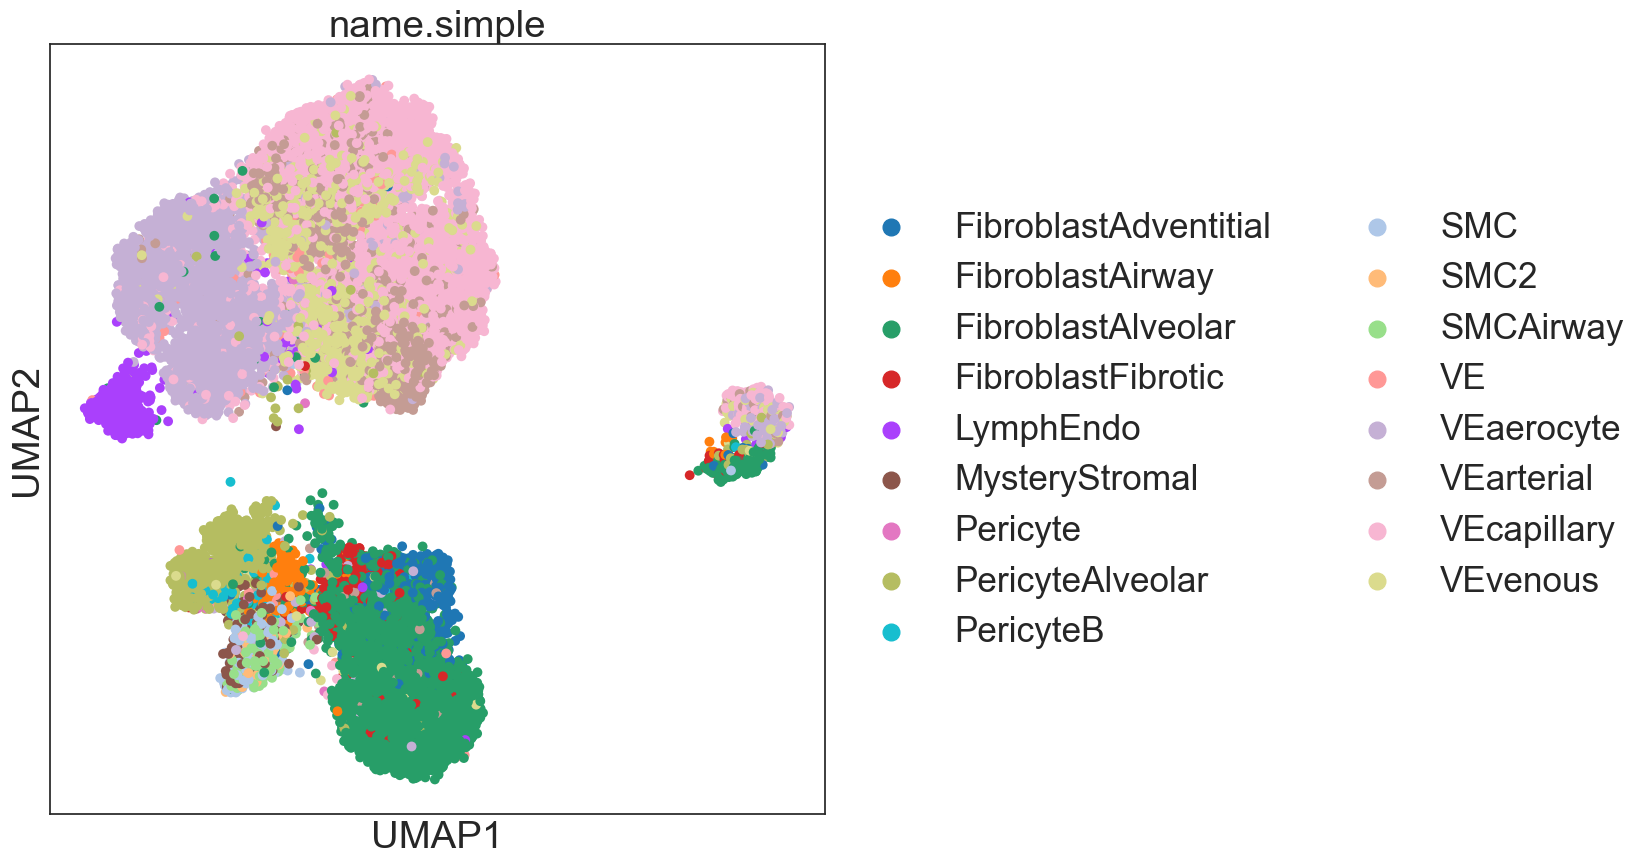

In [101]:
embex.plot_embs(embs=embs, 
                plot_style="umap",
                output_directory="/disk1/cai029/Caufussion/Benchmark_Disentangled/Geneformer/",  
                output_prefix="emb_plot",
                max_ncells_to_plot = 27647)

In [102]:
import pandas as pd

# 假设 df 有一列叫 cell_ids
# df.columns -> [..., "cell_ids"]

# 1. 把 cell_embsids 设置为索引
df_indexed = embs.set_index("cell_id")

# 2. 重新排序，使之与 adata.obs_names 对齐
embs = df_indexed.loc[adata.obs_names]

In [103]:
embs.index = adata.obs_names
del embs['stage']
del embs['name.simple']

In [104]:
import anndata as ad
adata.obsm['X_gene'] = embs 
adata.obsm['X_gene'].columns = adata.obsm['X_gene'].columns.astype(str)

In [105]:
# import scanpy as sc
# adata = sc.read_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/Geneformer/Geneformer.h5ad")

In [106]:
geneformer_adata = adata.copy()

In [107]:
geneformer_adata.obs = geneformer_adata.obs.iloc[:, :0] 
geneformer_adata.obs['name.simple'] = adata.obs['name.simple']
geneformer_adata.obs['stage'] = adata.obs['stage']
sc.pp.neighbors(geneformer_adata, use_rep='X_gene')
sc.tl.leiden(geneformer_adata, resolution=1.0, key_added="leiden")

In [108]:
import numpy as np
import pandas as pd
from collections import Counter

# y_true: 真实标签 (比如 ["B cell", "T cell", "Neuron", ...])
# listResult: 预测的聚类结果 (比如 [1,0,3,2,2,6,...])

df = pd.DataFrame({"true": geneformer_adata.obs['name.simple'].tolist(), "pred": geneformer_adata.obs['leiden'].tolist()})

mapping = {}
for cluster_id, group in df.groupby("pred"):
    most_common = Counter(group["true"]).most_common(1)[0][0]
    mapping[cluster_id] = most_common

print("预测簇 → 对应真实类型:")
print(mapping)

# 应用映射
y_pred_mapped = [mapping[c] for c in geneformer_adata.obs['leiden'].tolist()]

预测簇 → 对应真实类型:
{'0': 'VEaerocyte', '1': 'VEcapillary', '10': 'VEcapillary', '11': 'LymphEndo', '12': 'VEcapillary', '13': 'FibroblastAirway', '14': 'VEaerocyte', '2': 'FibroblastAlveolar', '3': 'VEcapillary', '4': 'VEvenous', '5': 'FibroblastAlveolar', '6': 'VEarterial', '7': 'VEvenous', '8': 'PericyteAlveolar', '9': 'SMC'}


In [109]:
geneformer_adata.obs['pred'] = y_pred_mapped

In [110]:
geneformer_adata.write_h5ad("/disk1/cai029/Caufussion/Benchmark_Disentangled/Geneformer/Geneformer.h5ad")